In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

print("Libraries loaded successfully.")

Libraries loaded successfully.


In [2]:
df = pd.read_csv('WA_Fn-UseC_-HR-Employee-Attrition.csv')

print(f"Dataset shape: {df.shape}")
df.head()

Dataset shape: (1470, 35)


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype
---  ------                    --------------  -----
 0   Age                       1470 non-null   int64
 1   Attrition                 1470 non-null   str  
 2   BusinessTravel            1470 non-null   str  
 3   DailyRate                 1470 non-null   int64
 4   Department                1470 non-null   str  
 5   DistanceFromHome          1470 non-null   int64
 6   Education                 1470 non-null   int64
 7   EducationField            1470 non-null   str  
 8   EmployeeCount             1470 non-null   int64
 9   EmployeeNumber            1470 non-null   int64
 10  EnvironmentSatisfaction   1470 non-null   int64
 11  Gender                    1470 non-null   str  
 12  HourlyRate                1470 non-null   int64
 13  JobInvolvement            1470 non-null   int64
 14  JobLevel                  1470 non-null   int64
 15

In [4]:
null_check = df.isnull().sum()
print("Null values per column:")
print(null_check[null_check > 0])
print(f"\nTotal missing values: {df.isnull().sum().sum()}")

Null values per column:
Series([], dtype: int64)

Total missing values: 0


Raw counts:
Attrition
No     1233
Yes     237
Name: count, dtype: int64

Percentages:
Attrition
No     83.9
Yes    16.1
Name: proportion, dtype: float64


C:\Users\nickg\AppData\Local\Temp\ipykernel_8608\1307554577.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Attrition', data=df, palette='Blues_d')


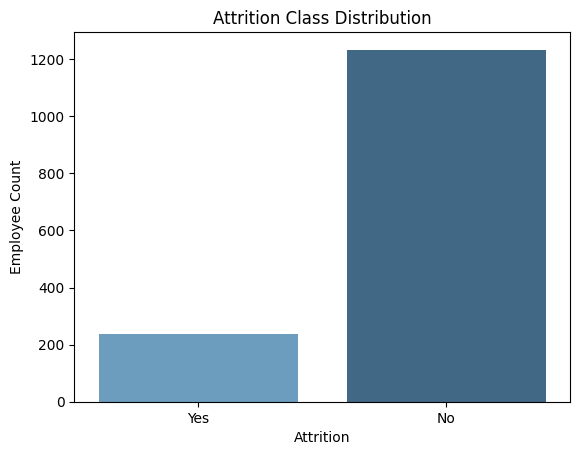

In [5]:
attrition_counts = df['Attrition'].value_counts()
attrition_pct = df['Attrition'].value_counts(normalize=True) * 100

print("Raw counts:")
print(attrition_counts)
print("\nPercentages:")
print(attrition_pct.round(1))

sns.countplot(x='Attrition', data=df, palette='Blues_d')
plt.title('Attrition Class Distribution')
plt.ylabel('Employee Count')
plt.show()

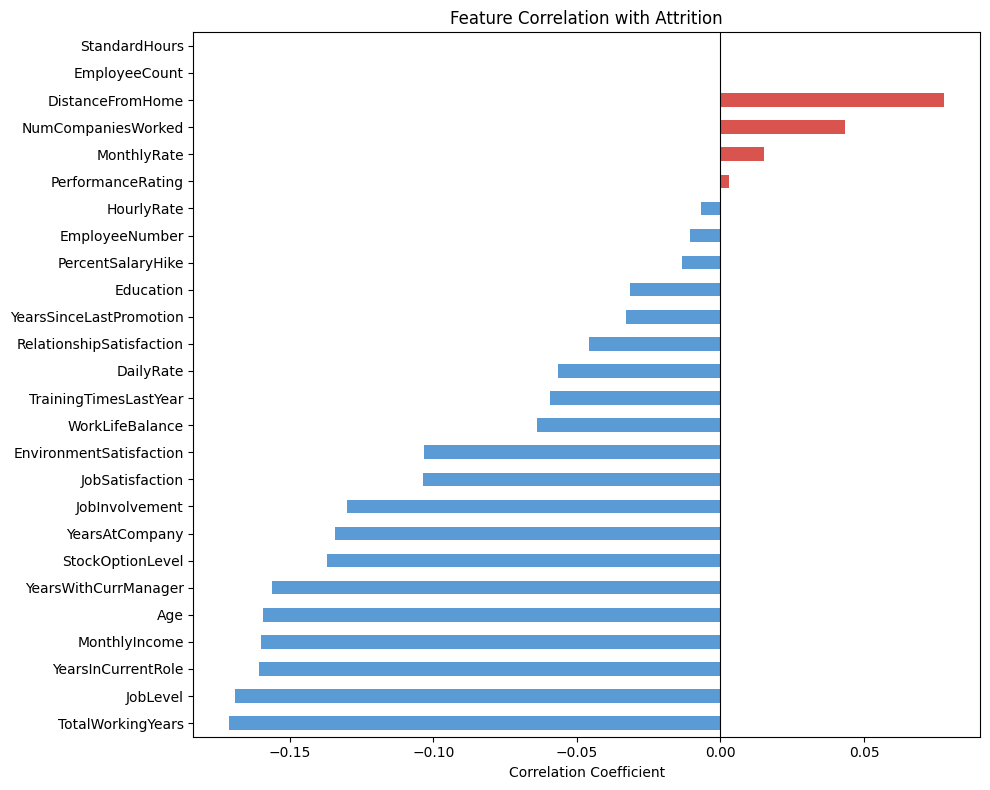

In [6]:
# Convert Attrition to numeric temporarily for correlation
df_corr = df.copy()
df_corr['Attrition_Num'] = (df_corr['Attrition'] == 'Yes').astype(int)

# Calculate correlation of numeric columns with Attrition
corr = df_corr.select_dtypes(include='int64').corr()['Attrition_Num'].drop('Attrition_Num')

# Sort and plot
corr_sorted = corr.sort_values()
plt.figure(figsize=(10, 8))
corr_sorted.plot(kind='barh', color=corr_sorted.map(lambda x: '#d9534f' if x > 0 else '#5b9bd5'))
plt.title('Feature Correlation with Attrition')
plt.xlabel('Correlation Coefficient')
plt.axvline(x=0, color='black', linewidth=0.8)
plt.tight_layout()
plt.show()

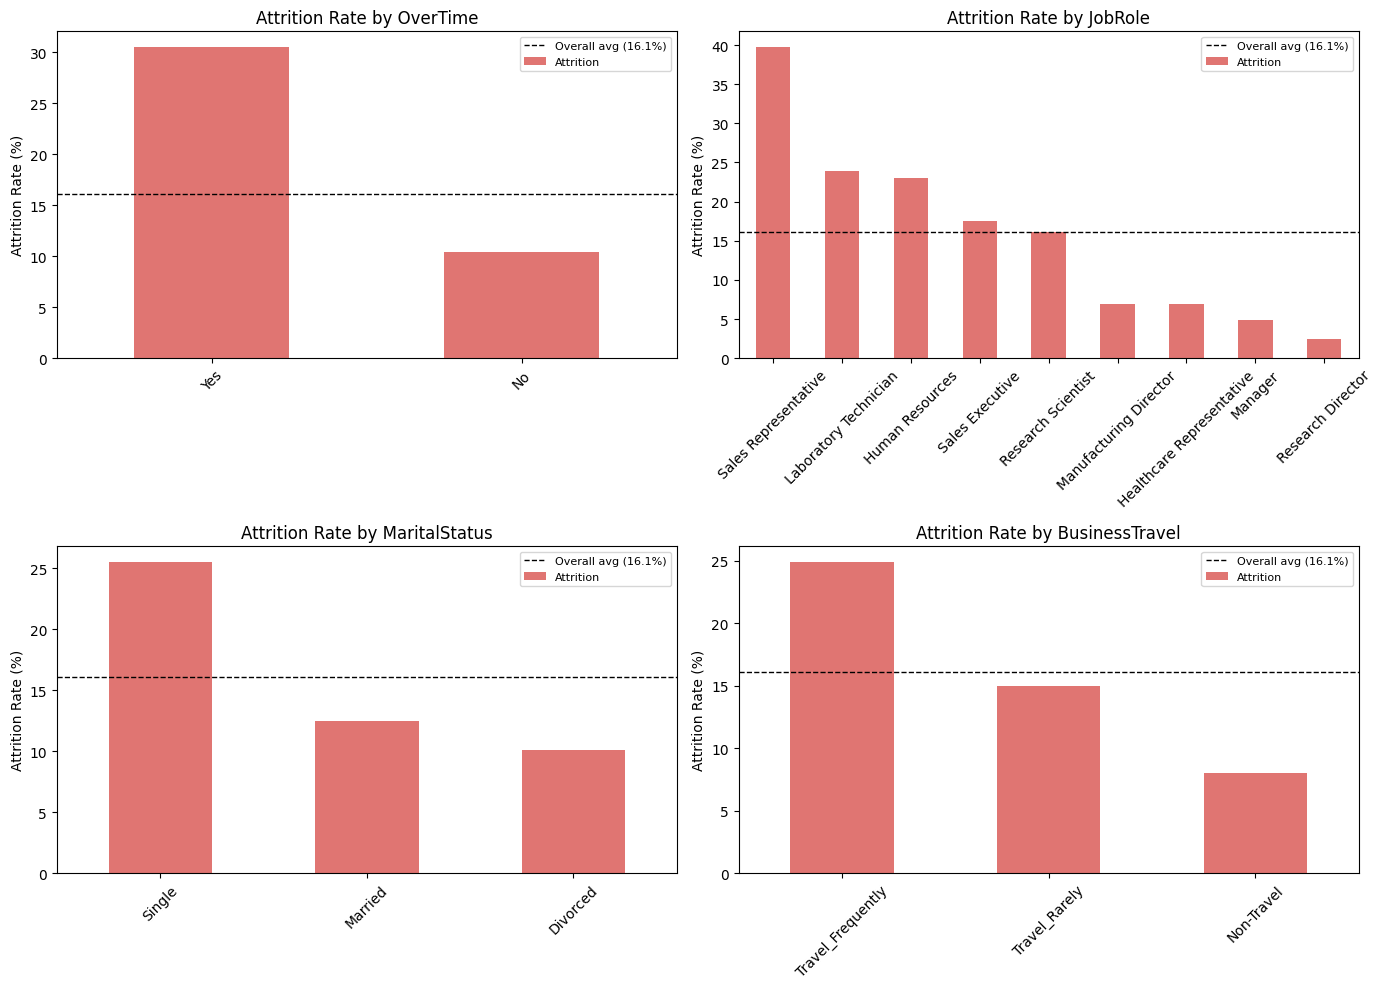

In [7]:
# Calculate attrition rate for each categorical variable
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

categoricals = {
    'OverTime': axes[0, 0],
    'JobRole': axes[0, 1],
    'MaritalStatus': axes[1, 0],
    'BusinessTravel': axes[1, 1]
}

for feature, ax in categoricals.items():
    attrition_rate = df.groupby(feature)['Attrition'].apply(
        lambda x: (x == 'Yes').mean() * 100
    ).sort_values(ascending=False)
    
    attrition_rate.plot(kind='bar', ax=ax, color='#d9534f', alpha=0.8)
    ax.set_title(f'Attrition Rate by {feature}')
    ax.set_ylabel('Attrition Rate (%)')
    ax.set_xlabel('')
    ax.tick_params(axis='x', rotation=45)
    ax.axhline(y=16.1, color='black', linewidth=1, linestyle='--', label='Overall avg (16.1%)')
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [8]:
# Drop columns that are constants or identifiers, not predictors
cols_to_drop = ['EmployeeCount', 'EmployeeNumber', 'Over18', 'StandardHours']

df_model = df.drop(columns=cols_to_drop)

print(f"Columns before: {df.shape[1]}")
print(f"Columns after: {df_model.shape[1]}")
print(f"\nRemaining columns:\n{list(df_model.columns)}")

Columns before: 35
Columns after: 31

Remaining columns:
['Age', 'Attrition', 'BusinessTravel', 'DailyRate', 'Department', 'DistanceFromHome', 'Education', 'EducationField', 'EnvironmentSatisfaction', 'Gender', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobRole', 'JobSatisfaction', 'MaritalStatus', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'OverTime', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager']


In [9]:
# Encode the target variable first
df_model['Attrition'] = (df_model['Attrition'] == 'Yes').astype(int)

# Encode all remaining categorical columns
df_model = pd.get_dummies(df_model, columns=[
    'BusinessTravel', 'Department', 'EducationField',
    'Gender', 'JobRole', 'MaritalStatus', 'OverTime'
], drop_first=True)

print(f"Columns after encoding: {df_model.shape[1]}")
print(f"\nSample of new columns:\n{list(df_model.columns)}")

Columns after encoding: 45

Sample of new columns:
['Age', 'Attrition', 'DailyRate', 'DistanceFromHome', 'Education', 'EnvironmentSatisfaction', 'HourlyRate', 'JobInvolvement', 'JobLevel', 'JobSatisfaction', 'MonthlyIncome', 'MonthlyRate', 'NumCompaniesWorked', 'PercentSalaryHike', 'PerformanceRating', 'RelationshipSatisfaction', 'StockOptionLevel', 'TotalWorkingYears', 'TrainingTimesLastYear', 'WorkLifeBalance', 'YearsAtCompany', 'YearsInCurrentRole', 'YearsSinceLastPromotion', 'YearsWithCurrManager', 'BusinessTravel_Travel_Frequently', 'BusinessTravel_Travel_Rarely', 'Department_Research & Development', 'Department_Sales', 'EducationField_Life Sciences', 'EducationField_Marketing', 'EducationField_Medical', 'EducationField_Other', 'EducationField_Technical Degree', 'Gender_Male', 'JobRole_Human Resources', 'JobRole_Laboratory Technician', 'JobRole_Manager', 'JobRole_Manufacturing Director', 'JobRole_Research Director', 'JobRole_Research Scientist', 'JobRole_Sales Executive', 'JobRole

In [10]:
from sklearn.model_selection import train_test_split

# Separate your predictors (X) from your target (y)
X = df_model.drop(columns=['Attrition'])
y = df_model['Attrition']

# Split into training and test sets
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Training set: {X_train.shape[0]} employees")
print(f"Test set: {X_test.shape[0]} employees")
print(f"\nAttrition rate in training set: {y_train.mean()*100:.1f}%")
print(f"Attrition rate in test set: {y_test.mean()*100:.1f}%")

Training set: 1176 employees
Test set: 294 employees

Attrition rate in training set: 16.2%
Attrition rate in test set: 16.0%


In [11]:
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler

# Scale your numeric features
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Train the model
model = LogisticRegression(class_weight='balanced', random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

print("Model trained successfully.")
print(f"\nFeatures used: {X_train.shape[1]}")
print(f"Training employees: {X_train.shape[0]}")

Model trained successfully.

Features used: 44
Training employees: 1176


AUC-ROC Score: 0.798

Classification Report:
              precision    recall  f1-score   support

      Stayed       0.91      0.78      0.84       247
        Left       0.35      0.62      0.44        47

    accuracy                           0.75       294
   macro avg       0.63      0.70      0.64       294
weighted avg       0.82      0.75      0.78       294



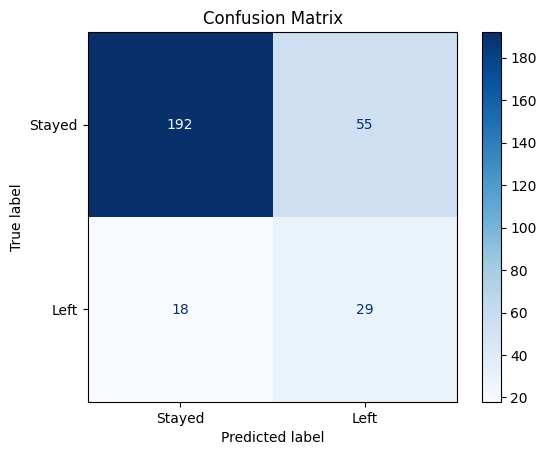

In [12]:
from sklearn.metrics import (classification_report, confusion_matrix, 
                             roc_auc_score, ConfusionMatrixDisplay)
import numpy as np

# Generate predictions
y_pred = model.predict(X_test_scaled)
y_pred_proba = model.predict_proba(X_test_scaled)[:, 1]

# AUC-ROC Score
auc_score = roc_auc_score(y_test, y_pred_proba)
print(f"AUC-ROC Score: {auc_score:.3f}")

# Classification Report
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=['Stayed', 'Left']))

# Confusion Matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stayed', 'Left'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix')
plt.show()

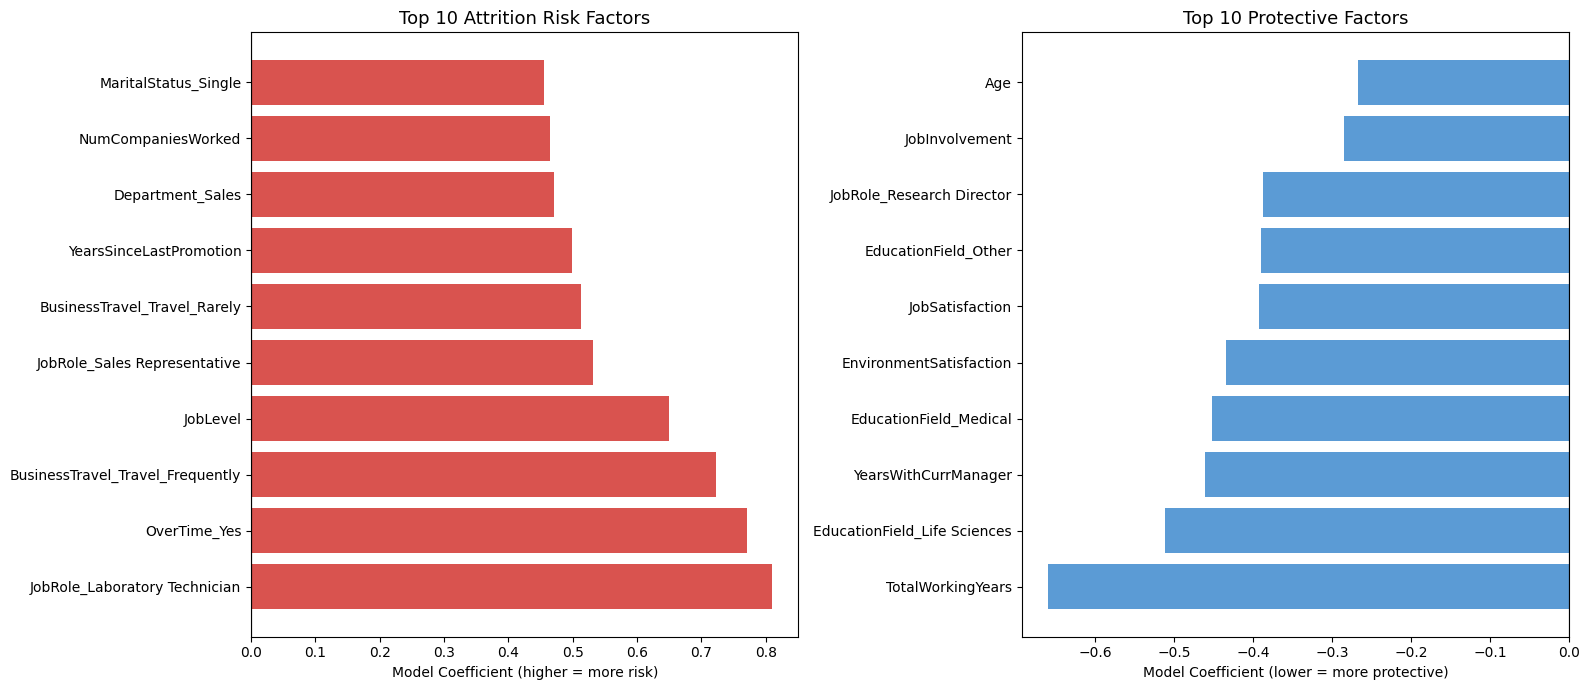

Top 5 Risk Factors:
                         Feature  Coefficient
   JobRole_Laboratory Technician     0.810172
                    OverTime_Yes     0.771095
BusinessTravel_Travel_Frequently     0.722538
                        JobLevel     0.650173
    JobRole_Sales Representative     0.531090

Top 5 Protective Factors:
                     Feature  Coefficient
           TotalWorkingYears    -0.660270
EducationField_Life Sciences    -0.512319
        YearsWithCurrManager    -0.461322
      EducationField_Medical    -0.452134
     EnvironmentSatisfaction    -0.434370


In [13]:
# Extract coefficients from the trained model
feature_names = X_train.columns
coefficients = model.coef_[0]

# Build a clean dataframe of features and their weights
importance_df = pd.DataFrame({
    'Feature': feature_names,
    'Coefficient': coefficients
}).sort_values('Coefficient', ascending=False)

# Plot top 10 risk factors and top 10 protective factors
top_risk = importance_df.head(10)
top_protective = importance_df.tail(10).sort_values('Coefficient')

fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Risk factors (positive coefficients)
axes[0].barh(top_risk['Feature'], top_risk['Coefficient'], color='#d9534f')
axes[0].set_title('Top 10 Attrition Risk Factors', fontsize=13)
axes[0].set_xlabel('Model Coefficient (higher = more risk)')
axes[0].axvline(x=0, color='black', linewidth=0.8)

# Protective factors (negative coefficients)
axes[1].barh(top_protective['Feature'], top_protective['Coefficient'], color='#5b9bd5')
axes[1].set_title('Top 10 Protective Factors', fontsize=13)
axes[1].set_xlabel('Model Coefficient (lower = more protective)')
axes[1].axvline(x=0, color='black', linewidth=0.8)

plt.tight_layout()
plt.show()

# Print the top 5 of each for quick reference
print("Top 5 Risk Factors:")
print(importance_df.head(5)[['Feature', 'Coefficient']].to_string(index=False))
print("\nTop 5 Protective Factors:")
print(importance_df.tail(5).sort_values('Coefficient')[['Feature', 'Coefficient']].to_string(index=False))

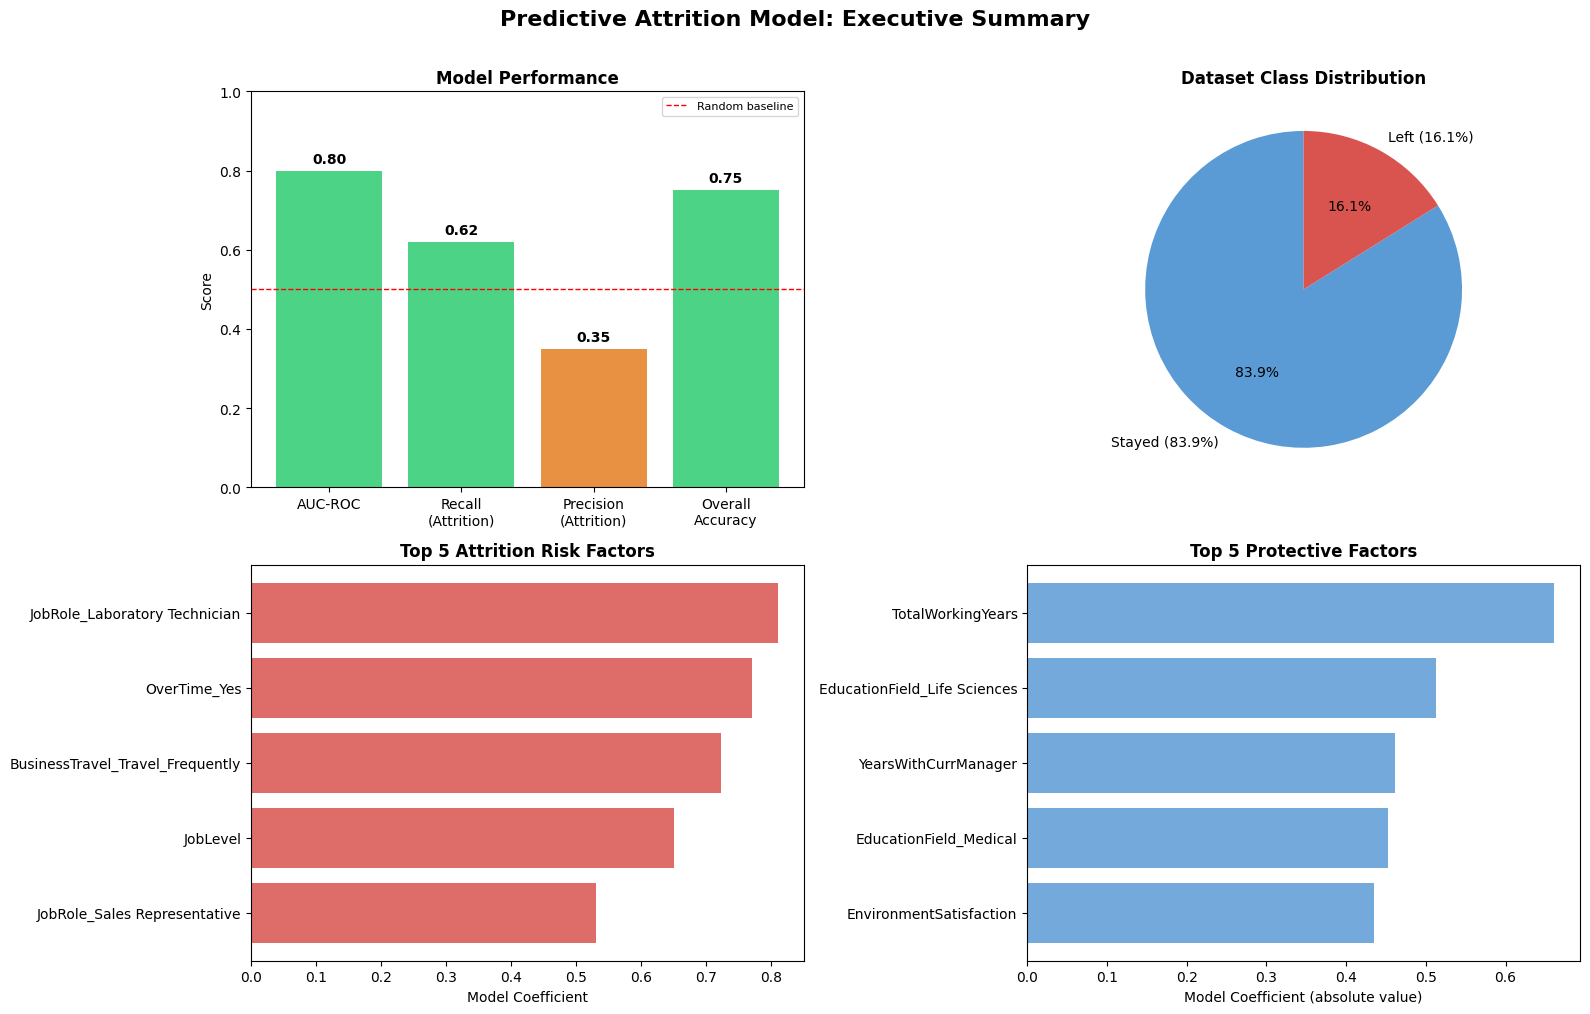

Summary chart saved as 'attrition_model_summary.png'


In [14]:
# Executive Summary: Key Model Findings
fig = plt.figure(figsize=(16, 10))
fig.suptitle('Predictive Attrition Model: Executive Summary', 
             fontsize=16, fontweight='bold', y=1.01)

# --- Panel 1: Model Performance ---
ax1 = fig.add_subplot(2, 2, 1)
metrics = ['AUC-ROC', 'Recall\n(Attrition)', 'Precision\n(Attrition)', 'Overall\nAccuracy']
values = [0.798, 0.62, 0.35, 0.75]
colors = ['#2ecc71' if v >= 0.6 else '#e67e22' for v in values]
bars = ax1.bar(metrics, values, color=colors, alpha=0.85)
ax1.set_ylim(0, 1)
ax1.axhline(y=0.5, color='red', linewidth=1, linestyle='--', label='Random baseline')
ax1.set_title('Model Performance', fontsize=12, fontweight='bold')
ax1.set_ylabel('Score')
ax1.legend(fontsize=8)
for bar, val in zip(bars, values):
    ax1.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.02,
             f'{val:.2f}', ha='center', fontsize=10, fontweight='bold')

# --- Panel 2: Class Distribution ---
ax2 = fig.add_subplot(2, 2, 2)
labels = ['Stayed (83.9%)', 'Left (16.1%)']
sizes = [1233, 237]
colors_pie = ['#5b9bd5', '#d9534f']
ax2.pie(sizes, labels=labels, colors=colors_pie, autopct='%1.1f%%',
        startangle=90, textprops={'fontsize': 10})
ax2.set_title('Dataset Class Distribution', fontsize=12, fontweight='bold')

# --- Panel 3: Top Risk Factors ---
ax3 = fig.add_subplot(2, 2, 3)
top5_risk = importance_df.head(5)
ax3.barh(top5_risk['Feature'], top5_risk['Coefficient'], color='#d9534f', alpha=0.85)
ax3.set_title('Top 5 Attrition Risk Factors', fontsize=12, fontweight='bold')
ax3.set_xlabel('Model Coefficient')
ax3.invert_yaxis()

# --- Panel 4: Top Protective Factors ---
ax4 = fig.add_subplot(2, 2, 4)
top5_protective = importance_df.tail(5).sort_values('Coefficient')
ax4.barh(top5_protective['Feature'], top5_protective['Coefficient'].abs(), color='#5b9bd5', alpha=0.85)
ax4.set_title('Top 5 Protective Factors', fontsize=12, fontweight='bold')
ax4.set_xlabel('Model Coefficient (absolute value)')
ax4.invert_yaxis()

plt.tight_layout()
plt.savefig('attrition_model_summary.png', dpi=150, bbox_inches='tight')
plt.show()

print("Summary chart saved as 'attrition_model_summary.png'")